# EDA - PWC Multilabel Dataset
Analisi esplorativa del dataset multilabel estratto da Papers With Code (PWC).
Le label associate a ciascun record sono separate da `|`.

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

In [32]:
# 1. Caricamento Dati
df_multilabel = pd.read_csv('../data/processed/pwc_ai_multilabel.csv')
print(f"Dimensioni dataset: {df_multilabel.shape}")
display(df_multilabel.head())

Dimensioni dataset: (326546, 2)


,description,labels
0,Can evolving networks be inferred and modeled ...,model|open ended question answering
1,This paper investigates the automated recognit...,big bench machine learning
2,In order to provide the right type of assistan...,self supervised learning|surgical phase recogn...
3,Many estimators of the average effect of a tre...,regression
4,A unified approach to explain the output of an...,big bench machine learning


In [33]:
# 2. Parsing delle Label
# Creiamo una lista di label per ogni record dividendo per '|'
df_multilabel['labels_list'] = df_multilabel['labels'].fillna('').apply(lambda x: [l for l in str(x).split('|') if l.strip()])

# Calcolo del numero di label per record (Cardinality)
df_multilabel['label_count'] = df_multilabel['labels_list'].apply(len)

print("Statistiche Cardinalità delle label:")
display(df_multilabel['label_count'].describe())

Statistiche Cardinalità delle label:


count    326546.000000
mean          2.658149
std           1.692716
min           1.000000
25%           1.000000
50%           2.000000
75%           4.000000
max         147.000000
Name: label_count, dtype: float64

/var/folders/5_/mnr70g2511s9w_v5w224k2x00000gn/T/ipykernel_75010/3714631290.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_multilabel, x='label_count', palette='viridis')


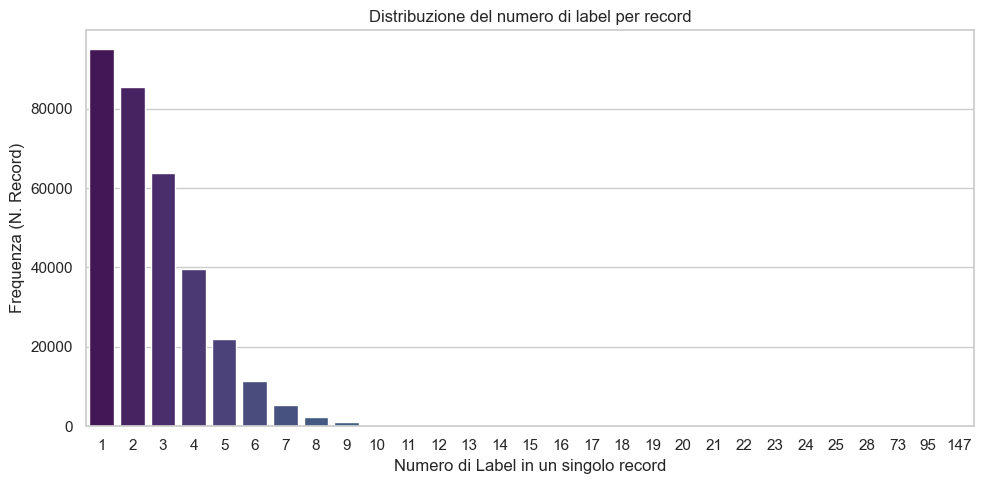

In [34]:
# 3. Distribuzione del Numero di Label per Record
plt.figure(figsize=(10, 5))
sns.countplot(data=df_multilabel, x='label_count', palette='viridis')
plt.title('Distribuzione del numero di label per record')
plt.xlabel('Numero di Label in un singolo record')
plt.ylabel('Frequenza (N. Record)')
plt.tight_layout()
plt.show()

Numero totale di singole label (uniche): 4616


/var/folders/5_/mnr70g2511s9w_v5w224k2x00000gn/T/ipykernel_75010/1568170942.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_label_freq.head(40), x='count', y='label', palette='mako')


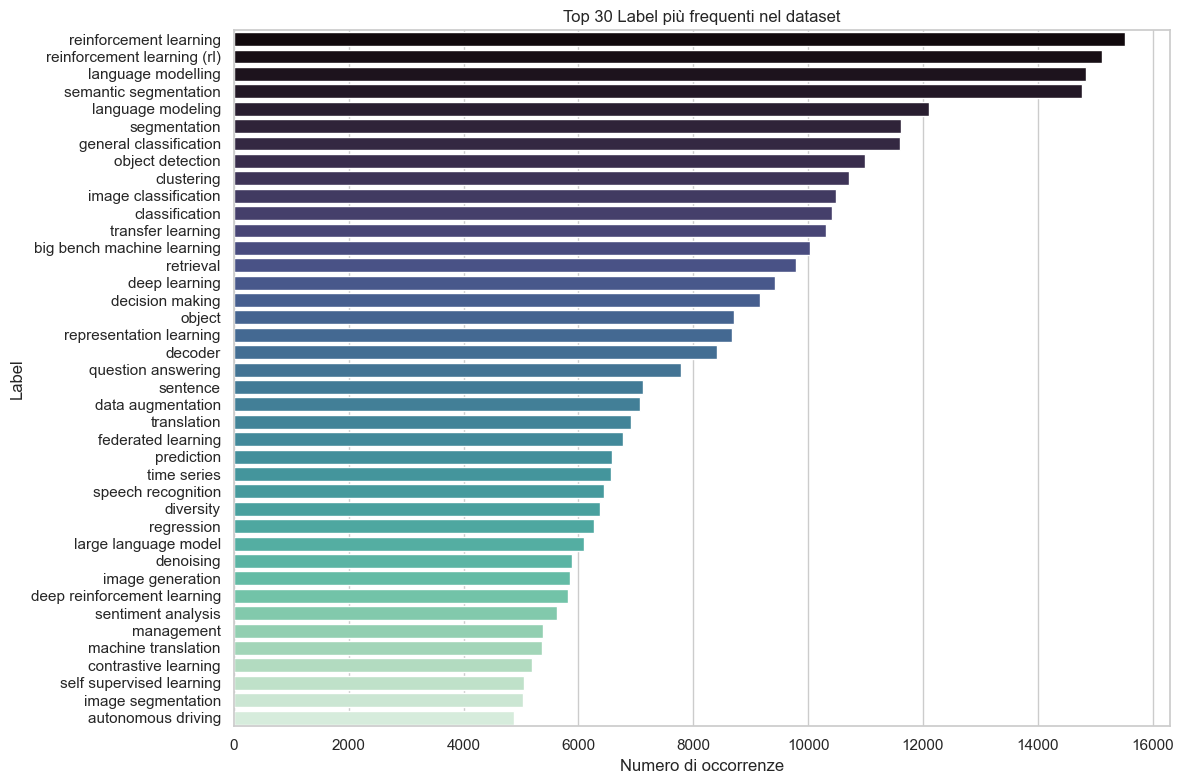

In [35]:
# 4. Frequenza delle Singole Label
all_labels = [label for labels in df_multilabel['labels_list'] for label in labels]
label_counts = Counter(all_labels)

print(f"Numero totale di singole label (uniche): {len(label_counts)}")

# Convertiamo in DataFrame per il plot
df_label_freq = pd.DataFrame.from_dict(label_counts, orient='index', columns=['count']).reset_index()
df_label_freq = df_label_freq.rename(columns={'index': 'label'}).sort_values('count', ascending=False)

plt.figure(figsize=(12, 8))
# Mostriamo le top 30 label
sns.barplot(data=df_label_freq.head(40), x='count', y='label', palette='mako')
plt.title('Top 30 Label più frequenti nel dataset')
plt.xlabel('Numero di occorrenze')
plt.ylabel('Label')
plt.tight_layout()
plt.show()

/var/folders/5_/mnr70g2511s9w_v5w224k2x00000gn/T/ipykernel_75010/368078864.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_multilabel[df_multilabel['label_count'] <= 50], x='label_count', y='desc_length', palette='Set2')


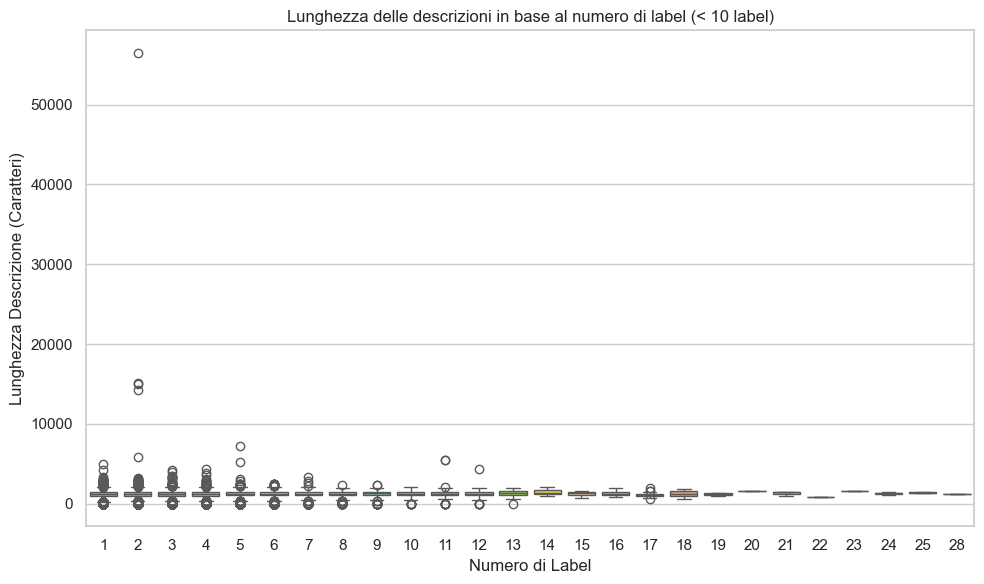

In [36]:
# 5. Lunghezza delle descrizioni basata sul numero di label
df_multilabel['desc_length'] = df_multilabel['description'].fillna('').astype(str).str.len()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_multilabel[df_multilabel['label_count'] <= 50], x='label_count', y='desc_length', palette='Set2')
plt.title('Lunghezza delle descrizioni in base al numero di label (< 10 label)')
plt.xlabel('Numero di Label')
plt.ylabel('Lunghezza Descrizione (Caratteri)')
plt.tight_layout()
plt.show()

In [37]:
# 6. Top 20 record con il maggior numero di label
print("Top 20 record con il maggior numero di label:")
display(df_multilabel.sort_values('label_count', ascending=False)[['description', 'labels', 'label_count']].head(20))

Top 20 record con il maggior numero di label:


,description,labels,label_count
140224,Language modelling provides a step towards int...,abstract algebra|anachronisms|analogical simil...,147
158081,The step function is one of the simplest and m...,10 shot image generation|16k|2d object detecti...,95
148563,We investigate the optimal model size and numb...,anachronisms|analogical similarity|analytic en...,73
188695,The use of NLP in the realm of financial techn...,causal judgment|common sense reasoning|date un...,28
103335,State-of-the-art computer vision systems are t...,action recognition|benchmarking|few shot image...,25
174659,Information overload is a major obstacle to sc...,anachronisms|bias detection|citation predictio...,25
40030,It is intuitive that NLP tasks for logographic...,chinese dependency parsing|chinese named entit...,24
22405,Subset selection from massive data with noised...,10 shot image generation|action recognition|co...,24
149412,Large language models have been shown to achie...,auto debugging|code generation|common sense re...,23
186605,"We report the development of GPT-4, a large-sc...",answerability prediction|arithmetic reasoning|...,22
